## Load the tokenizer

In [52]:
import sys
sys.path.append('..')

In [53]:
import sys
from pathlib import Path

# The tutorial's own package (transformer/) sits one level up from Notebooks/.
tutorial_root = Path.cwd().parent
sys.path.insert(0, str(tutorial_root))

try:
    import minbpe
except ModuleNotFoundError:
    for repo_root in (Path.cwd(), *Path.cwd().parents):
        if (repo_root / "minbpe" / "minbpe" / "base.py").exists():
            sys.path.insert(0, str(repo_root / "minbpe"))
            print("using minbpe clone at:", repo_root / "minbpe")
            break
    else:
        raise ModuleNotFoundError(
            "minbpe not found. Install it with "
            "`pip install git+https://github.com/karpathy/minbpe.git`"
        )
else:
    print("using installed minbpe:", Path(minbpe.__file__).parent)

print("tutorial root:", tutorial_root)

using installed minbpe: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/minbpe/minbpe
tutorial root: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial


In [54]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [55]:
import torch
torch.manual_seed(3647)

In [56]:
from transformer.model import GPTLanguageModel

block_size = 512
n_embd = 128
n_head = 8
n_layer = 1
dropout = 0.2
batch_size = 128
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

0.529418 M parameters


## Data preparation

### 1. Load the data

In [57]:
with open("../output/combined_text.txt", "r") as f:
    text_sequence = f.read()

encoded_text_sequence = tokenizer.encode(text_sequence)
len(encoded_text_sequence)

195429

### 2. Split it into train and test

In [58]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9*len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [59]:
from typing import Tuple


def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    index = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in index])
    y = torch.stack([data[i+1:i+block_size+1] for i in index])
    x, y = x.to(device), y.to(device)
    return x, y

In [60]:
x, y = get_batch('train')
x.shape, y.shape

(torch.Size([128, 512]), torch.Size([128, 512]))

### 4. Training

In [61]:
from typing import Dict

eval_iters = 200


@torch.no_grad()
def estimate_loss() -> Dict:
    output = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()
        output[split] = losses.mean()
    model.train()
    return output

In [62]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    # torch.save will not create missing parents, so a run directory that does
    # not exist yet raises FileNotFoundError at the first save - after training
    # has already been running.
    path = Path(file_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, path)

In [63]:
max_iters = 1000
eval_interval = 10
learning_rate = 1e-4
save_interval = 100
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for iteration in range(max_iters):
    if iteration % eval_interval == 0 or iteration == max_iters - 1:
        losses = estimate_loss()
        print(
            f"step {iteration}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval == 0:
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=iteration,
            loss=loss.item(),
            file_path=f"../output/pre_training/run_1/checkpoint_{iteration}.pth"
        )

step 0: train loss 6.9570, val loss 6.9571
step 10: train loss 6.7966, val loss 6.8095
step 20: train loss 6.6748, val loss 6.6901
step 30: train loss 6.5732, val loss 6.5904
step 40: train loss 6.4853, val loss 6.5066
step 50: train loss 6.4091, val loss 6.4341
step 60: train loss 6.3430, val loss 6.3722
step 70: train loss 6.2859, val loss 6.3186
step 80: train loss 6.2351, val loss 6.2720
step 90: train loss 6.1875, val loss 6.2285
step 100: train loss 6.1383, val loss 6.1837
step 110: train loss 6.0856, val loss 6.1364
step 120: train loss 6.0279, val loss 6.0833
step 130: train loss 5.9646, val loss 6.0245
step 140: train loss 5.8993, val loss 5.9620
step 150: train loss 5.8334, val loss 5.8982
step 160: train loss 5.7716, val loss 5.8385
step 170: train loss 5.7108, val loss 5.7823
step 180: train loss 5.6542, val loss 5.7306
step 190: train loss 5.6026, val loss 5.6811
step 200: train loss 5.5534, val loss 5.6377
step 210: train loss 5.5070, val loss 5.5950
step 220: train loss 

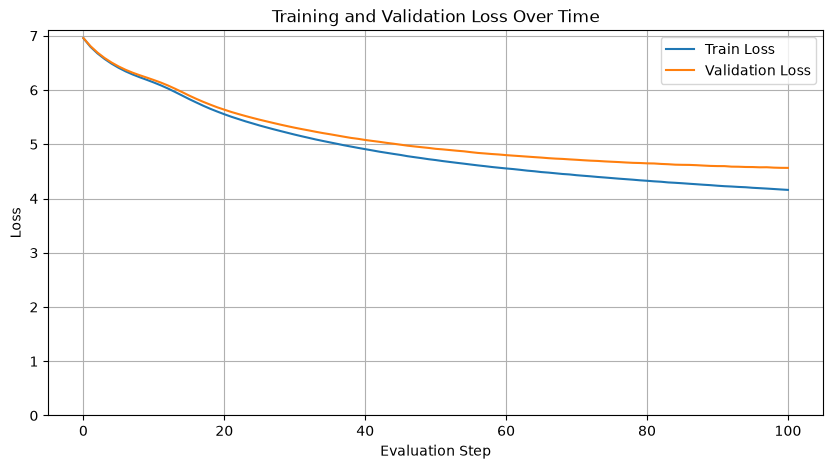

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [66]:
input_tokens = tokenizer.encode("Hello")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=50)

print(tokenizer.decode(output[0].tolist()))

Hellolit for the murcy lle preed now but i missout stose to sprough one works then's the raining this week work trip she said ok haha love, minut extra more dr
